# The Machine Learning Workflow

**DCS 404 · Data Science and Machine Learning**

---

Last time we answered *what* machine learning is. Today we tackle a question that sounds simpler but trips up
far more people: once you actually have a problem to solve, *what do you do first, and what do you do next?*

Here's something I've watched happen too many times. A student learns a dozen algorithms, can recite the maths
behind gradient descent, and then sits down in front of a real dataset and freezes — because knowing the tools
is not the same as knowing the process. A project doesn't fail because you picked logistic regression over a
random forest. It fails because nobody defined what "success" meant, or because a crucial feature was missing
and nobody noticed until the very end, or because the model looked brilliant in testing and fell apart the
moment it met the real world.

So today we're going to learn the *process* — a battle-tested recipe called CRISP-DM that professional data
scientists have leaned on since the 1990s — and we're going to walk it end to end on a real dataset, writing
real code at every step, all the way from "here's a business problem" to "here's a saved model ready to
deploy." By the end you'll have built a complete machine learning project, not just a model.

Let's get organised.

## How to work through this

Same deal as last time. Run every code cell (`Shift + Enter`) and actually look at the output before you read
my commentary underneath — the whole notebook is built around *seeing* the result first and then making sense
of it.

A couple of things specific to today. This module uses a real dataset (student records from two Portuguese
schools), and I've bundled it in the `data/` folder next to this notebook, so everything runs offline. And
because this is a *workflow*, the cells build on each other in order — the cleaning step depends on the
loading step, the model depends on the cleaning, and so on. If something errors, the usual cause is running
cells out of order; just run from the top.

As before, watch for the moments where I stop and ask you something or suggest a change to try. They're where
the real learning happens.

## Learning objectives

After completing this module you will be able to:

- Describe the six phases of the CRISP-DM workflow and explain why a structured process matters.
- Turn a vague business goal into a concrete, measurable machine learning problem.
- Explore an unfamiliar dataset: summarise it, visualise its distributions and relationships, and check its
  quality for missing values, outliers, and imbalance.
- Prepare raw data for modelling by cleaning it, encoding categorical variables, and splitting it correctly.
- Train, evaluate, and compare regression models using appropriate metrics.
- Understand what "deployment" involves, including saving and reloading a trained model.

## Setup

Run this once. It loads our libraries, sets a consistent plotting style, and reads in the dataset we'll use
all the way through. If an import fails, install it with `pip install <package>`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# A consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 0

# Load the Student Performance dataset. It is semicolon-separated, not comma-separated.
# We look in a couple of likely locations so this runs whether you launched Jupyter
# from the repo root or from inside the notebooks/ folder.
for candidate in [Path("data/student-mat.csv"),
                  Path("notebooks/data/student-mat.csv"),
                  Path("resources/dataset/student-mat.csv")]:
    if candidate.exists():
        df = pd.read_csv(candidate, sep=";")
        print(f"Loaded dataset from: {candidate}")
        break
else:
    raise FileNotFoundError("Could not find student-mat.csv. Expected it in a data/ folder next to the notebook.")

print(f"Shape: {df.shape[0]} students, {df.shape[1]} columns")
df.head()

Loaded dataset from: data/student-mat.csv
Shape: 395 students, 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


---
## 1. The map: CRISP-DM

Before we touch the data, let me give you the map we'll be following. It's called **CRISP-DM** — the
Cross-Industry Standard Process for Data Mining — and despite the mouthful of a name, the idea is
down-to-earth. It's simply a checklist of the six stages that almost every data project moves through, dreamt
up back in the late 1990s and still the default playbook in industry today.

The six phases are:

1. **Business Understanding** — what are we actually trying to achieve, and how will we know if we succeeded?

2. **Data Understanding** — what data do we have, and what shape is it in?

3. **Data Preparation** — cleaning and reshaping the raw data into something a model can eat.

4. **Modelling** — the part everyone thinks of as "machine learning": training the actual model.

5. **Evaluation** — did it work? Is it good enough to trust?

6. **Deployment** — putting the model to work in the real world.

Why bother with a formal process at all? Because, as the old saying goes, *a problem well defined is a problem
half solved.* You can be brilliant at algorithms and still sink a project through plain disorganisation.
Imagine getting all the way to evaluation only to discover the one feature that actually predicts your target
was never collected — weeks of work, gone. CRISP-DM exists to catch that kind of thing early, by making sure
you do the right things in the right order.

And one crucial detail before we start: this is a **loop, not a line.** You'll often reach evaluation, realise
your data wasn't good enough, and circle right back to preparation — or even back to redefining the problem.
That's not failure; that's the process working as intended. Let me draw it.

<center>

<img src ="resources/images/crispdm.png" width = "900" height ="700">


Fig: CRISP-DM Process flow 
</center>


---
## 2. Phase 1 — Business Understanding

This is the phase everyone is tempted to skip, and it's the one that most often decides whether a project
lives or dies. Before a single line of code, we ask: *what are we trying to accomplish, and why?* Concretely,
this phase is about defining the problem, understanding who the result is for, taking stock of the data and
resources we have, and — critically — deciding up front what "success" will look like.

Let me make it real with the scenario we'll use all module. Picture a school that wants to **spot students at
risk of a poor final grade early enough to help them.** A counsellor can only give extra attention to a
handful of students, so a vague "some kids are struggling" isn't actionable. They need something specific.

So we translate that wish into a concrete machine learning problem:

- **The goal.** Predict a student's final grade (`G3`, on a 0–20 scale) from information available about them.

- **The task type.** The target is a number, so this is *regression* — the flavour of supervised learning we
  met in Module 1 with the temperature example.

- **Who it's for.** School counsellors, who will use the predictions to prioritise who to support.

- **What success looks like.** On average, our predictions should land within about two grade points of the
  truth. (We'll define exactly how we measure that when we reach evaluation.)

Notice we haven't mentioned an algorithm yet. That's deliberate. The problem definition comes first; the tool
comes later. Now that we know what we're chasing, let's go and meet the data.

---
## 3. Phase 2 — Data Understanding

Now we get to know our data. This is where **exploratory data analysis (EDA)** lives — the detective work of
summarising a dataset and letting it surprise you before you commit to any modelling. Rush this phase and
you'll pay for it later, every time.

### 3.1 Where data comes from

Our data arrived as a tidy CSV file, but that's the easy case. In real projects data comes from all over:
plain text and delimited files, relational and NoSQL databases, web scraping and APIs, live streams. And it
comes in two broad shapes. **Structured** data is the neat, tabular kind — rows and columns, numbers and
categories — the sort you can drop straight into a spreadsheet, like ours. **Unstructured** data is
everything messier: free text, images, audio, video. Most of the world's data is unstructured, which is
exactly why it's so valuable and so hard to work with. Today we're firmly in structured-data territory, which
is the right place to learn the workflow.

This phase is primarily divided into the following sub-steps:

- Data Acquisition: Gathering data

  - Plain text files, delimited files, JSON files

  - Databases (Relational or NOSQL)

  - Web Scraping and APIs

  - URLs, Streaming data


- Data Exploration with verification of its quality

  - Quick Summary of data

  - Attribute Information

  - Descriptive Statistics

  - Histogram, bar plots

  - Correlation Matrix
  
  - Data Quality(DQ) Verification


You should develop the habit of creating a simple document with at least a description of the ideal data needed to test a hypothesis. This will help you:

- Streamline the modeling process.
- Ensure that all the future data come in an improved form.



Data needs to be there to start any data science project or data analysis project. The diagram below represents the common methods of gathering or collecting data.

<center>

<img src ="resources/images/datacollection.png" width = "650" height ="450">

Fig: Different ways of Data collection.
</center>

There are different sites in internet such as: _Kaggle_ and _UCI Machine learning Repository_ , from where we can collect the data for machine learning projects.




### 3.2 The dataset: student performance

We're using the **Student Performance** dataset from the UCI Machine Learning Repository (Cortez & Silva,
2008): real records from two Portuguese secondary schools, gathered from school reports and questionnaires.
It has 395 students and 33 columns — 32 input features plus the target.

The features paint a rounded picture of each student. A few worth knowing about now:

| Feature | Meaning |
|---|---|
| `sex`, `age`, `address` | basic demographics |
| `studytime`, `failures`, `absences` | study habits and history |
| `Medu`, `Fedu`, `Mjob`, `Fjob` | parents' education and jobs |
| `goout`, `Dalc`, `Walc`, `health` | lifestyle (social life, alcohol, health) |
| `G1`, `G2` | grades from the first and second periods |
| **`G3`** | **the final grade — this is our target** |

That last group is worth a mental flag already: `G1` and `G2` are earlier grades for the same student, so
we'd expect them to be very strong predictors of the final grade `G3`. Hold that thought — it'll come back
to bite us in an interesting way.

### 3.3 A quick summary

The very first thing I do with any new dataset is ask pandas for a quick summary: how many rows and columns,
what the data types are, and whether anything is missing. `df.info()` gives all of that at a glance.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [3]:
# How many columns are text (categorical) versus numeric? This shapes our whole preparation plan later.
n_categorical = df.select_dtypes(include="object").shape[1]
n_numeric = df.select_dtypes(include=np.number).shape[1]
print(f"Categorical (text) features : {n_categorical}")
print(f"Numeric features            : {n_numeric}")
print(f"Total                       : {n_categorical + n_numeric}")

Categorical (text) features : 17
Numeric features            : 16
Total                       : 33


/var/folders/qr/z61dfxk90914kcsdy7jskgqr0000gn/T/ipykernel_8094/3426734064.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  n_categorical = df.select_dtypes(include="object").shape[1]


So we've got a mix: some columns are numbers already, but a good chunk are text like `"yes"`/`"no"` or
`"teacher"`. File that away — machine learning models only speak numbers, so every one of those text columns
will need converting before we can model. That's a job for Phase 3.

### 3.4 Descriptive statistics

Numbers and text want summarising differently. For the numeric columns we ask for the classic five-number
summary — mean, spread, min, max, quartiles. For the text columns those don't make sense, so instead we ask
how many unique values each has and which is most common.

In [4]:
# Summary of the numeric columns
df.describe(include=[np.number])

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
# Summary of the categorical (text) columns
df.describe(include=["object"])

/var/folders/qr/z61dfxk90914kcsdy7jskgqr0000gn/T/ipykernel_8094/1805765710.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object"])


,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no
freq,349,208,307,281,354,141,217,145,273,344,242,214,201,314,375,329,263


Already there are things to notice. Look at `absences`: the average is a handful of days, but the maximum is
enormous compared to the typical value — a hint that a few students skew things badly, which we'll confirm
when we hunt for outliers. And in the categorical summary you can see, for instance, which school most
students attend. This is the kind of quiet familiarity with the data that pays off later.

### 3.5 Distributions: histograms

Summary numbers hide the *shape* of the data. A histogram fixes that by bucketing each feature into ranges and
counting how many students fall in each — turning a column of numbers into a picture you can read in a second.

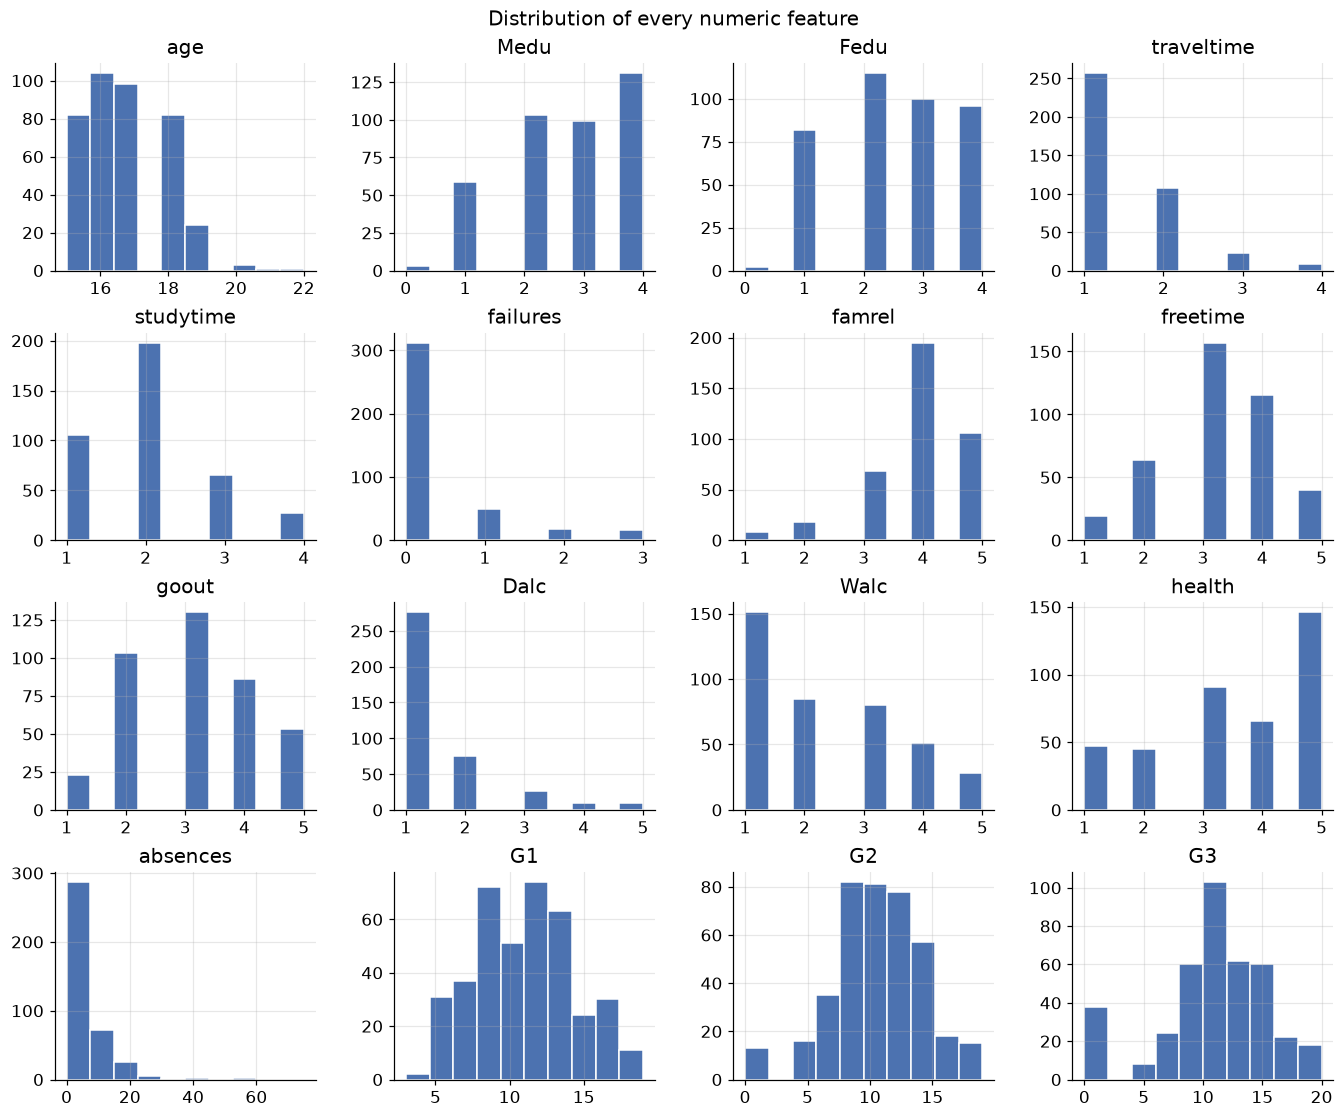

In [6]:
# One histogram per numeric feature
axes = df.select_dtypes(include=np.number).hist(figsize=(15, 12), edgecolor="white")
plt.suptitle("Distribution of every numeric feature", y=0.92, fontsize=13)
plt.show()

These little pictures are full of stories. `absences` is heavily skewed — most students miss few classes, a
handful miss many. `failures` is lopsided too: the vast majority have zero past failures. And crucially, look
at `G3`, our target: it's roughly bell-shaped but with a suspicious spike at zero — students who scored 0 on
the final. Those zeros are real and they'll matter. Reading distributions like this is a skill worth
practising; it tells you what you're dealing with before any model does.

### 3.6 Relationships: the correlation matrix

Histograms show one feature at a time. But we also care how features move *together* — and especially how each
one relates to our target. A correlation matrix measures that for every pair of numeric features at once, on a
scale from -1 (move in opposite directions) through 0 (unrelated) to +1 (move together). A heatmap makes it
readable at a glance.

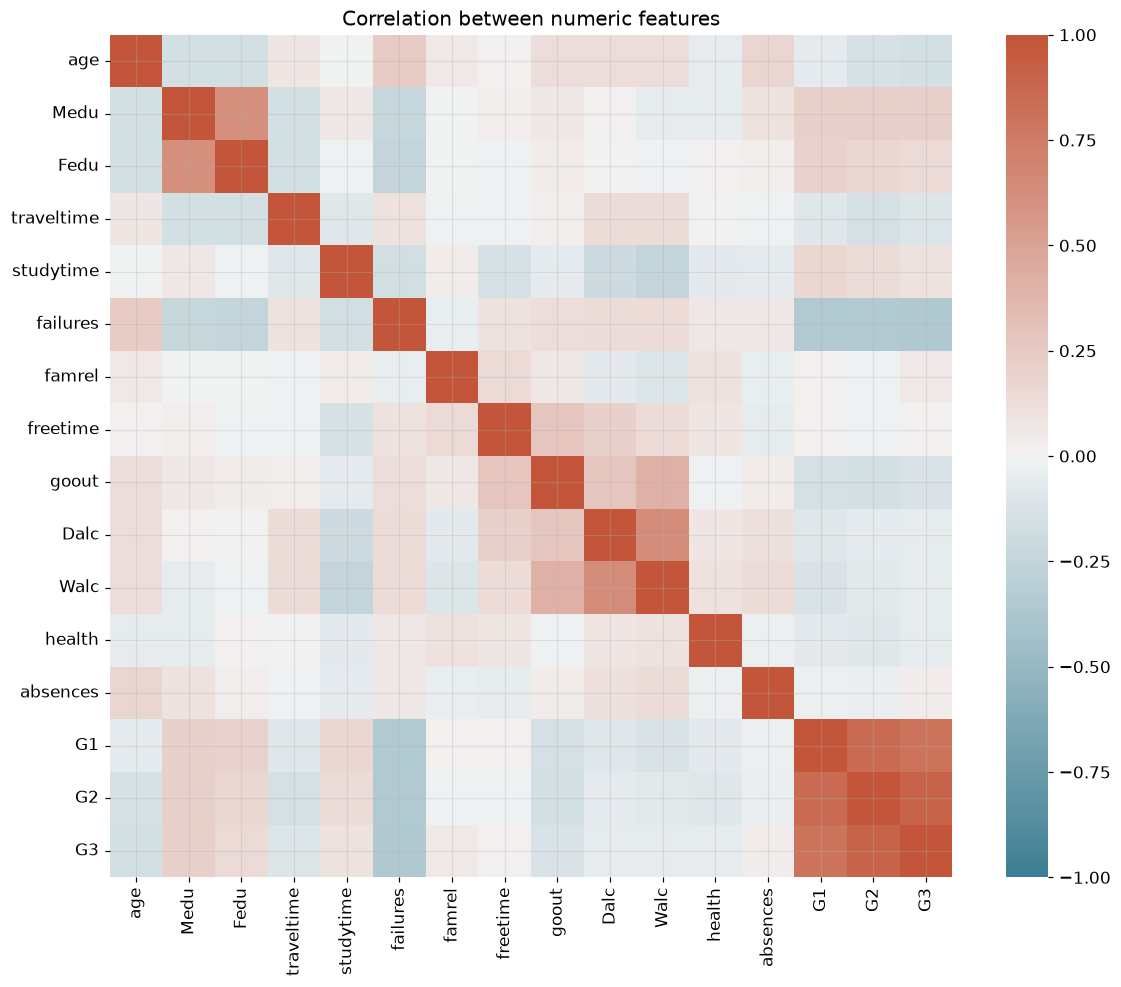

Strongest correlations with the final grade G3:
G2           0.90
G1           0.80
Medu         0.22
Fedu         0.15
studytime    0.10
famrel       0.05
Name: G3, dtype: float64


In [7]:
plt.figure(figsize=(11, 9))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, vmin=-1, vmax=1, center=0,
            cmap=sns.diverging_palette(220, 20, n=200), annot=False, square=True)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()

# Which features are most correlated with our target, G3?
print("Strongest correlations with the final grade G3:")
print(corr["G3"].drop("G3").sort_values(ascending=False).head(6).round(2))

And there's the payoff, in the printout: `G2` and `G1` are by far the strongest predictors of `G3`, which is
no surprise — a student's earlier grades tell you a lot about their final one. This is genuinely useful to
know before modelling. But it also plants a flag we'll return to: if our model leans almost entirely on `G1`
and `G2`, is it really doing anything clever, and would it even be usable *early* in the year before those
grades exist? Good questions. Park them for now.

### 3.7 The categorical features

Correlation is a numeric idea, so our text columns sat out that last plot. To get a feel for them we count how
often each category appears. Rather than drown you in all 17, here are two representative ones.

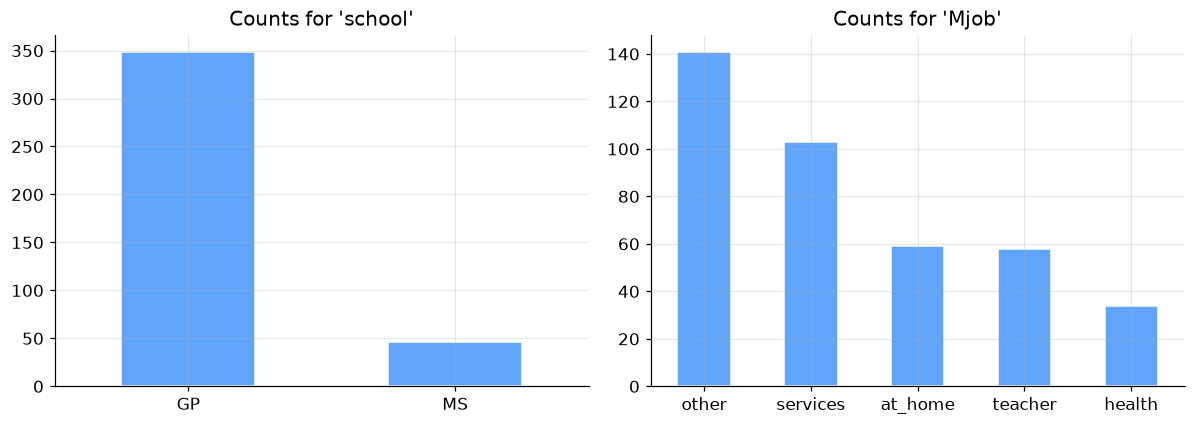

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["school", "Mjob"]):
    df[col].value_counts().plot(kind="bar", ax=ax, color="#60a5fa", edgecolor="white")
    ax.set_title(f"Counts for '{col}'")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

The heights tell you the balance of each category — most students come from one of the two schools, mothers'
jobs cluster in a few categories, and so on. Imbalances like these are worth noting because they can quietly
bias a model toward whatever it saw most of.

### 3.8 Data quality checks

Last stop in getting to know the data, and arguably the most important: is it any *good*? Three quick checks
catch most problems — missing values, outliers, and an imbalanced target.

In [9]:
# 1) Missing values: what fraction of each column is empty?
missing = df.isna().mean().sort_values(ascending=False)
print("Columns with the most missing values:")
print(missing.head().round(3))
print(f"\nTotal missing values in the entire dataset: {int(df.isna().sum().sum())}")

Columns with the most missing values:
school      0.0
paid        0.0
G2          0.0
G1          0.0
absences    0.0
dtype: float64

Total missing values in the entire dataset: 0


Good news — not a single missing value. That's rare in the real world (usually you're patching holes
everywhere), but it means we get to skip missing-data handling this time. We'll still talk about how you'd
handle it, because next time you won't be so lucky.

Now outliers — those extreme values that sit far from everything else. A boxplot is the classic way to spot
them: anything drawn as a dot beyond the "whiskers" is a candidate outlier.

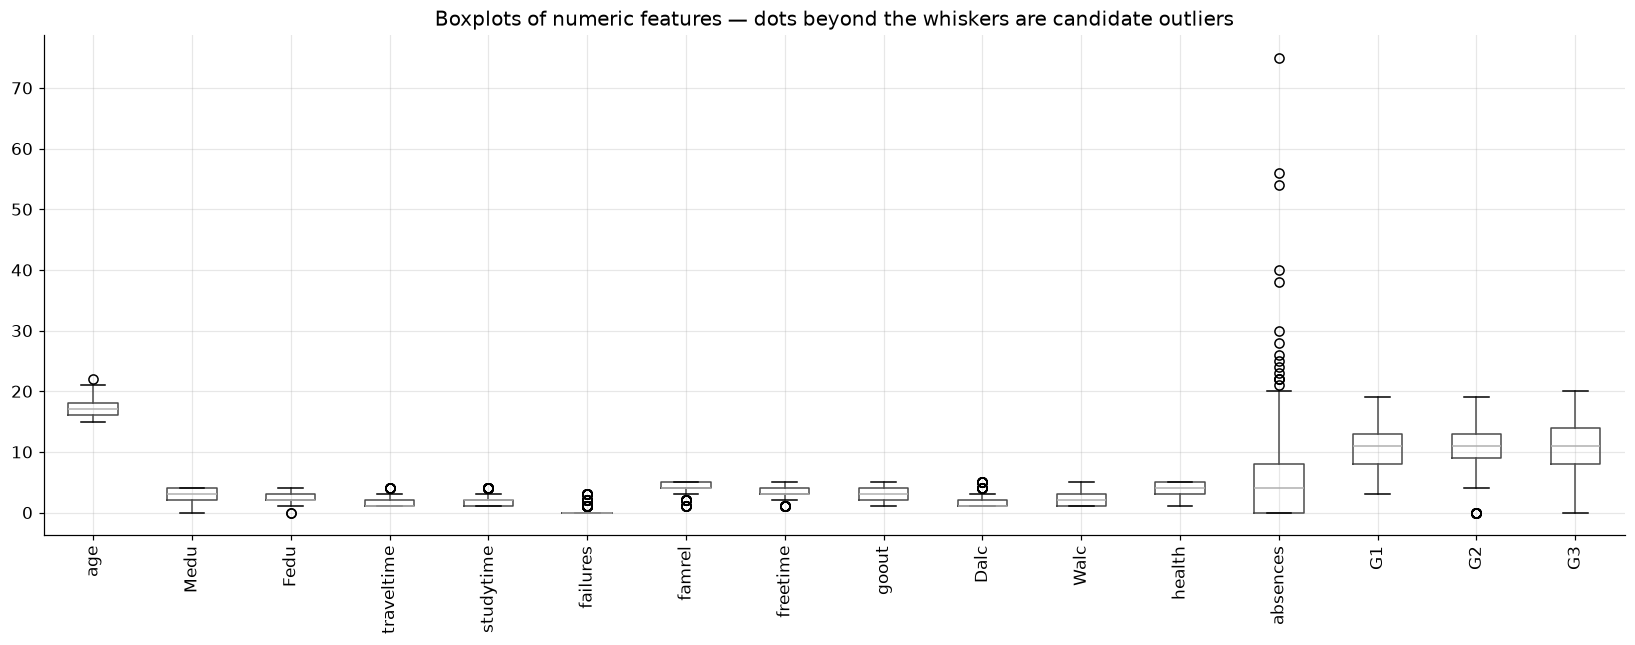

In [10]:
plt.figure(figsize=(15, 6))
df.select_dtypes(include=np.number).boxplot(rot=90)
plt.title("Boxplots of numeric features — dots beyond the whiskers are candidate outliers")
plt.tight_layout()
plt.show()

`absences` jumps out immediately, with a long tail of students way above the norm. A handful of features have
a few outliers too. We'll deal with `absences` in the preparation phase.

Finally, is our target balanced? For a regression target we just look at its distribution — if some grade
values are rare, the model will see few examples of them and struggle there.

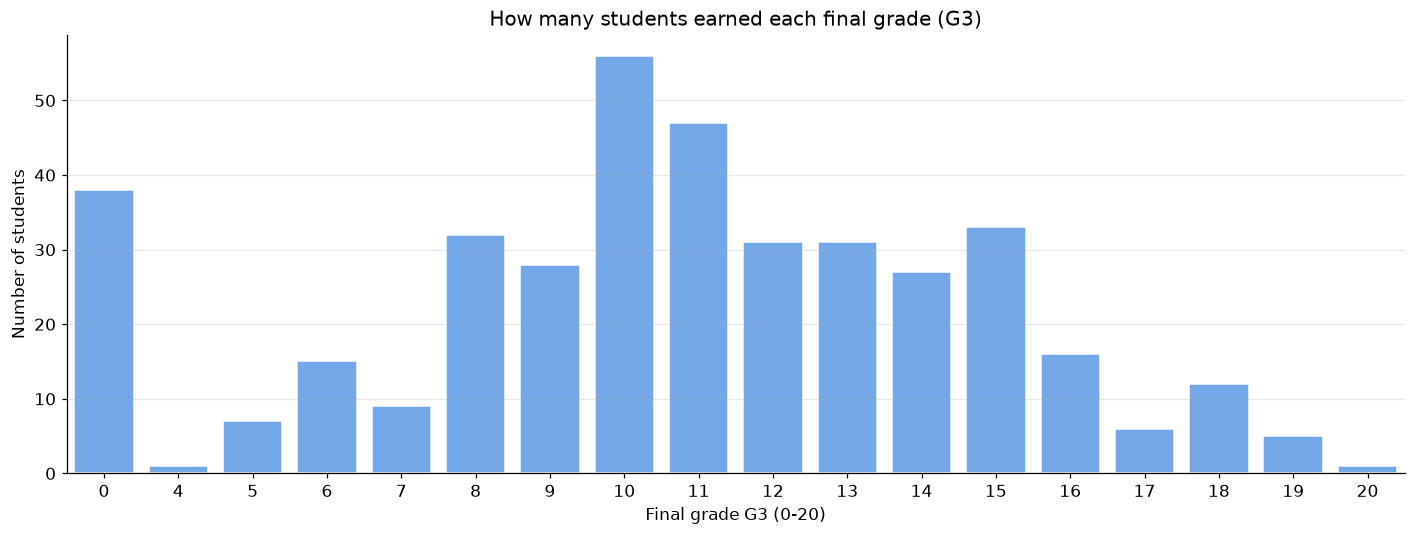

In [11]:
plt.figure(figsize=(13, 5))
sns.countplot(x="G3", data=df, color="#60a5fa", edgecolor="white")
plt.title("How many students earned each final grade (G3)")
plt.xlabel("Final grade G3 (0-20)"); plt.ylabel("Number of students")
plt.tight_layout()
plt.show()

This is imbalanced: some grades are common, others (the very low and very high ones) are represented by only a
few students. That spike at 0 we spotted earlier is clearly visible. It doesn't mean those students don't
count — quite the opposite — but it does mean the model will have less to learn from at the extremes, which is
worth remembering when we judge its performance.

That's Phase 2 done. We now know our data's shape, its distributions, its relationships, and its flaws. Time to
roll up our sleeves and prepare it.

---
## 4. Phase 3 — Data Preparation

Here's a statistic that surprises every new data scientist: this phase — cleaning and reshaping the data — is
where you'll spend the *majority* of your time on most real projects. It's unglamorous, nobody puts it in the
demo, and it matters enormously. A brilliant algorithm fed messy data produces messy predictions. Garbage in,
garbage out, exactly as we said last module.

We'll do three things: clean the data, encode the text columns into numbers, and split it for training and
testing.

### 4.1 Cleaning the data

Cleaning covers a lot of ground — handling missing values, taming outliers, removing duplicates, fixing typos.
Let me touch the two that matter here.

**Missing values.** We're lucky today; there are none. But you won't always be, so know your options. You can
*delete* rows or columns with missing data (simple, but you throw away information), or you can *impute* —
fill the gaps with the column's mean or median, or its most frequent value. Which one is right depends on how
much is missing and why.

**Outliers.** These we do have, in `absences`. Rather than delete those students (they're real, and deleting
data is a big decision), we'll *cap* the feature: any absence count above a sensible threshold gets pulled
down to that threshold. This keeps the student in the dataset while stopping a few extreme values from
dominating. Let me cap at 15 days.

In [12]:
# Cap the 'absences' outliers at 15 so a few extreme students don't dominate the model.
before_max = df["absences"].max()
df["absences"] = np.where(df["absences"] > 15, 15, df["absences"])
print(f"'absences' maximum before capping: {before_max}")
print(f"'absences' maximum after capping : {df['absences'].max()}")

'absences' maximum before capping: 75
'absences' maximum after capping : 15


### 4.2 Encoding the text columns

Remember our earlier flag: models only understand numbers, but 17 of our columns are text. We have to convert
them, and *how* we convert them depends on the kind of category.

**Label encoding** simply assigns each category a number: `no` becomes 0, `yes` becomes 1. This is perfect for
two-valued columns, and for columns with a real order to them. But it has a trap — it implies an *ordering*.
If we label-encoded `Mjob` as teacher=0, health=1, services=2, the model would wrongly assume services is
"more" than teacher, which is nonsense; job is not a quantity.

**One-hot encoding** solves that. For a column with no natural order, it creates a separate 0/1 column for
each category — a `Mjob_teacher` column, a `Mjob_health` column, and so on — so no false ordering sneaks in.
The cost is extra columns, but it's the honest choice for unordered ("nominal") categories.

So our plan: label-encode the yes/no binary columns, and one-hot encode the genuinely unordered ones.

In [13]:
from sklearn.preprocessing import LabelEncoder

# Genuinely unordered ("nominal") categories -> one-hot encode
cat_nominal = ["Mjob", "Fjob", "reason", "guardian"]
# Two-valued ("binary") categories -> label encode to 0/1
cat_binary = ["school", "sex", "address", "famsize", "Pstatus", "schoolsup",
              "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]

# Label-encode each binary column to 0/1
for col in cat_binary:
    df[col] = LabelEncoder().fit_transform(df[col])

# One-hot encode the nominal columns (dtype=int keeps them as clean 0/1 rather than True/False)
df = pd.get_dummies(df, columns=cat_nominal, prefix=cat_nominal, dtype=int)

print(f"After encoding, the dataset has {df.shape[1]} columns (it grew because of one-hot encoding).")
print("Every column is now numeric:", df.select_dtypes(include="object").empty)
df.head()

After encoding, the dataset has 46 columns (it grew because of one-hot encoding).
Every column is now numeric: True


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,0,0,18,1,0,0,4,4,2,2,...,0,0,1,1,0,0,0,0,1,0
1,0,0,17,1,0,1,1,1,1,2,...,1,0,0,1,0,0,0,1,0,0
2,0,0,15,1,1,1,1,1,1,2,...,1,0,0,0,0,1,0,0,1,0
3,0,0,15,1,0,1,4,2,1,3,...,0,1,0,0,1,0,0,0,1,0
4,0,0,16,1,0,1,3,3,1,2,...,1,0,0,0,1,0,0,1,0,0


Every column is a number now, and the dataset grew a little because one-hot encoding split each nominal column
into several. The data is finally in a form a model can consume.

### 4.3 Splitting into training and test sets

This last step is small in code and huge in importance, so let me be emphatic about it. We are going to split
our data into two piles. The model gets to learn from the **training set** only. The **test set** we lock in a
drawer and never let the model see during training — it's the final exam, our only honest measure of how the
model will do on students it has never encountered.

Why so strict? Because if you let a model study the test before grading it on the test, of course it scores
well — and that score is a lie. A model that has secretly seen the answers tells you nothing about the real
world. The whole point of holding data back is to keep ourselves honest. We'll use an 80/20 split: 80% to
learn from, 20% to be judged on.

<center>




<p>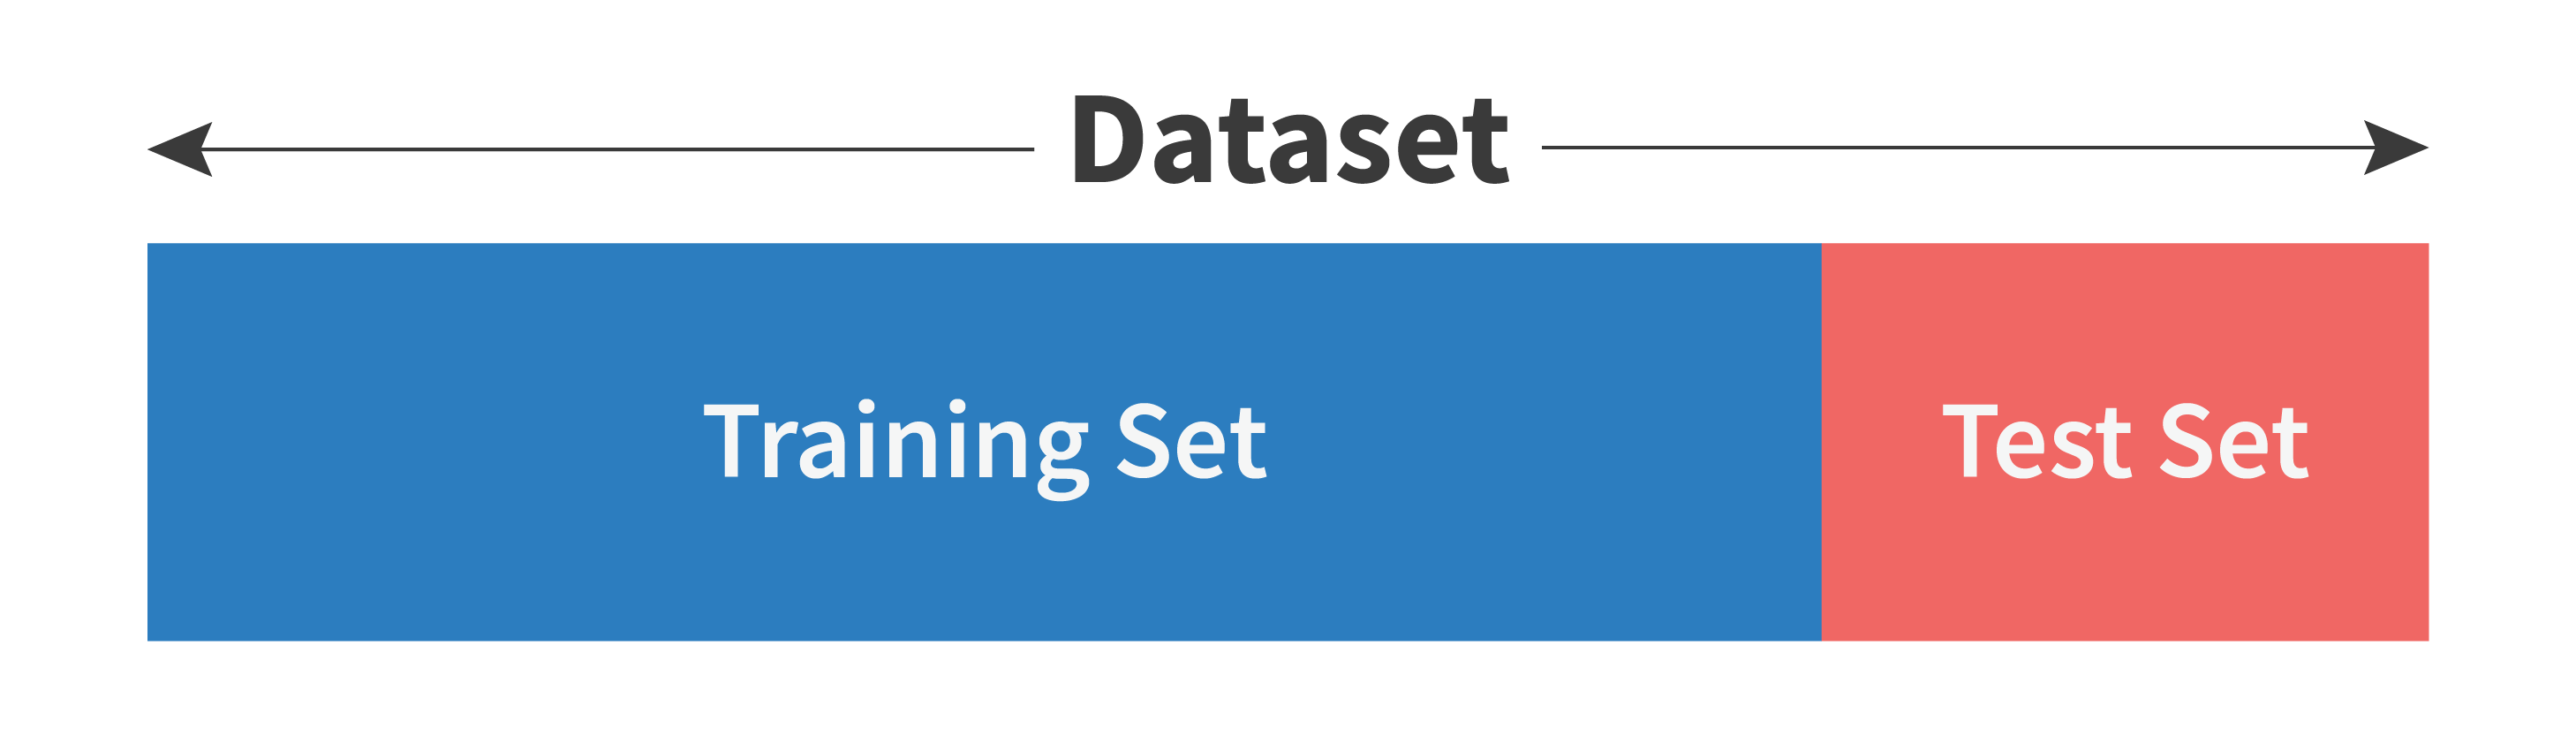</p>

Fig: Splitting Dataset
</center>



In [14]:
from sklearn.model_selection import train_test_split

y = df["G3"]                 # what we want to predict: the final grade
X = df.drop(columns=["G3"])  # everything else: the features

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Training set: {X_train.shape[0]} students  (the model learns from these)")
print(f"Test set    : {X_test.shape[0]} students  (locked away until evaluation)")

Training set: 316 students  (the model learns from these)
Test set    : 79 students  (locked away until evaluation)


One more idea to mention, because you'll meet it constantly: **feature scaling.** Some algorithms care a lot
about the *scale* of features — an `age` of 18 and an `absences` of 15 live on totally different number
ranges, and certain models get confused by that. Scaling squeezes every feature into a comparable range so no
single one dominates just because its numbers happen to be bigger. The model we're about to use, plain linear
regression, doesn't strictly need it, so we'll keep things simple here — but tuck the concept away, because
for algorithms like SVMs and KNN it's essential.

And that's data preparation. Cleaned, encoded, split. The unglamorous majority of the work is behind us — now
for the fun part.

---
## 5. Phase 4 — Modelling

This is the phase everyone shows up for. But notice how much had to happen before we got here — that's the
real lesson of the workflow. With clean, prepared data in hand, the modelling itself is almost anticlimactic.

Choosing a model means weighing a few things: the kind of problem (ours is regression), how much data we have,
how fast it needs to run, and how important it is that we can *explain* the model's decisions. We'll start with
the natural first choice for a regression problem: **linear regression**, the very model that rediscovered the
temperature formula last module. It's fast, and its simplicity makes it a great baseline — you always want a
simple model to measure fancier ones against.

Then, to see whether something more powerful helps, we'll also train a **random forest** — a model that
combines many decision trees (we'll unpack how it works in a later module). For now, treat it as a stronger,
more flexible competitor and let's see if it earns its keep.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Baseline: a simple, fast, interpretable linear model
linreg = LinearRegression()
linreg.fit(X_train, y_train)   # this line is where the learning happens

# Challenger: a more flexible ensemble of decision trees
forest = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
forest.fit(X_train, y_train)

print("Both models trained.")
print("Remember: they have only seen the training set. The test set is still locked away.")

Both models trained.
Remember: they have only seen the training set. The test set is still locked away.


That's it — two trained models. The `.fit()` call is where all the objective-and-optimization machinery from
Module 1 quietly ran. Now comes the moment of truth: are they any good?

---
## 6. Phase 5 — Evaluation

Training a model is easy. Knowing whether to *trust* it is the hard, essential part — and it's where we
finally open that locked drawer and test on data the models have never seen.

For a regression problem like ours, three metrics tell the story:

- **MAE (Mean Absolute Error)** — on average, how many grade points off are we? The most intuitive one: an
  MAE of 1.5 means our typical prediction misses by about 1.5 grades. Lower is better.
- **RMSE (Root Mean Squared Error)** — similar, but it squares the errors before averaging, so it punishes
  big misses much harder than small ones. Lower is better. If RMSE is much larger than MAE, you have some
  badly-wrong predictions dragging things up.
- **R² (R-squared)** — what fraction of the variation in grades the model actually explains, from 0 (useless,
  no better than always guessing the average) to 1 (perfect). Higher is better.

Let's compute all three, for both models, on the held-out test set.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, name):
    preds = model.predict(X_test)
    return {
        "Model": name,
        "MAE":  mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2":   r2_score(y_test, preds),
    }

results = pd.DataFrame([evaluate(linreg, "Linear Regression"),
                        evaluate(forest, "Random Forest")]).set_index("Model")
results.round(3)

,MAE,RMSE,R2
Model,,,
Linear Regression,1.583,2.339,0.802
Random Forest,1.133,1.894,0.870


Read that table like a scorecard. The MAE tells you, in plain grade points, how far off a typical prediction
is — and for both models it should be comfortably within the two-point target we set back in Business
Understanding. That's the number I'd actually report to the school counsellor, because it's the one they can
feel. Compare the two models and you'll see whether the random forest's extra complexity bought us anything;
often on tidy tabular data like this, the humble linear model is startlingly hard to beat, which is a lesson
in itself.

Numbers in a table are abstract, though. Let me *show* you how good the predictions are by plotting each
predicted grade against the student's actual grade. Perfect predictions would sit exactly on the diagonal
line; the tighter the cloud hugs that line, the better.

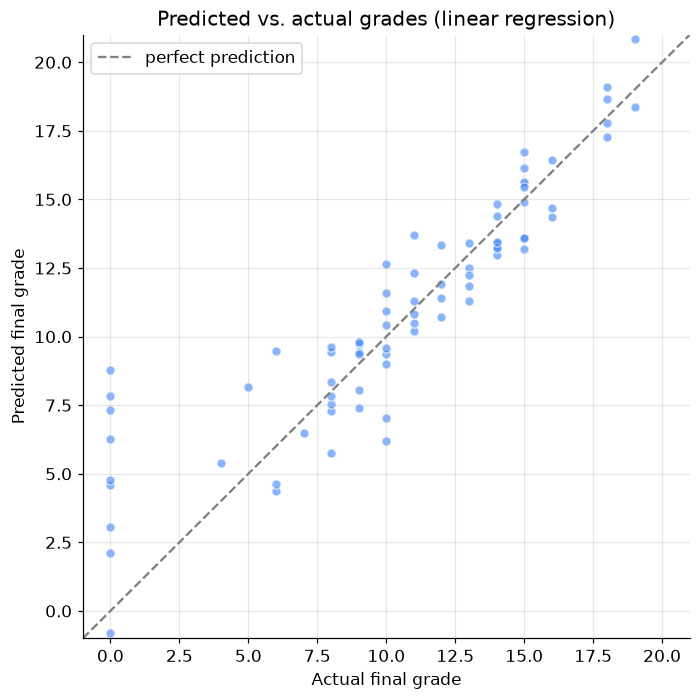

In [17]:
# Predicted vs actual for the linear model. The closer to the diagonal, the better.
preds = linreg.predict(X_test)

plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, preds, alpha=0.6, edgecolor="white", color="#3b82f6")
lims = [-1, 21]
plt.plot(lims, lims, "--", color="gray", label="perfect prediction")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual final grade")
plt.ylabel("Predicted final grade")
plt.title("Predicted vs. actual grades (linear regression)")
plt.legend()
plt.tight_layout()
plt.show()

Most points hug the diagonal nicely, which is what we want to see. But look at the bottom-left: the students
who actually scored 0 are predicted to have positive grades — the model refuses to believe in those zeros,
because they were rare and unusual (exactly the imbalance we flagged in Phase 2). This is the value of
plotting your results rather than trusting a single summary number: the picture shows you *where* the model
struggles, not just how much.

One more question every practitioner asks: *which features is the model actually leaning on?* A random forest
can tell us how important each feature was to its predictions. Let's look at the top few.

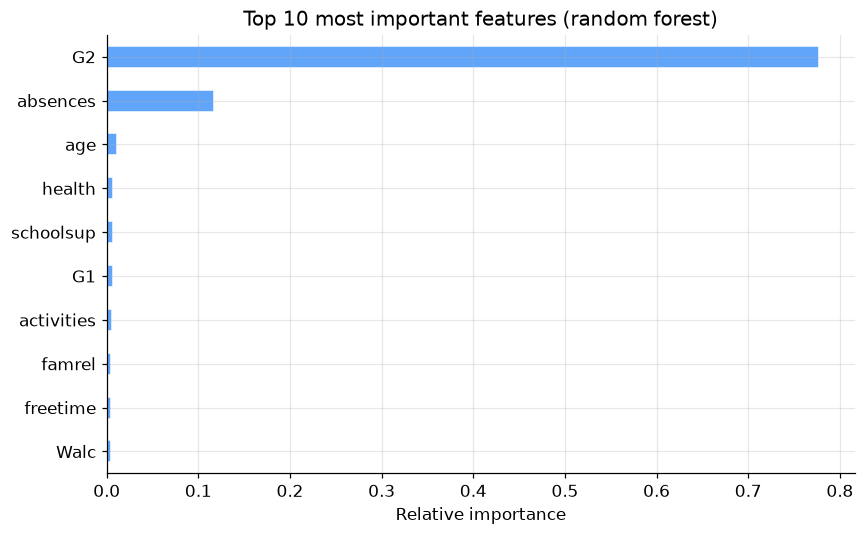

In [18]:
# The random forest's view of which features mattered most
importances = pd.Series(forest.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(10).iloc[::-1].plot(kind="barh", color="#60a5fa", edgecolor="white")
plt.title("Top 10 most important features (random forest)")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.show()

And there's the flag we planted way back in Phase 2, now fully raised: `G2` and `G1` dominate everything else.
The model is essentially predicting the final grade from the two grades just before it, which is accurate but
maybe not very *insightful* — and useless if a counsellor wants to intervene early in the year, before those
grades even exist. This is a genuine, real-world modelling dilemma, and it's a perfect example of why
evaluation loops back to the earlier phases: a school might well ask us to *drop* `G1` and `G2` and rebuild,
trading accuracy for a model that's actually usable when it matters. (That's one of your exercises.)

This is also the phase where we'd normally check for **overfitting** — a model that aced the training data but
flops on the test data, having memorised rather than learned. Comparing training and test scores is the usual
tell, and it's a theme we'll develop properly in later modules.

---
## 7. Phase 6 — Deployment

A model sitting in a notebook helps no one. Deployment is the final phase, where the model actually goes to
work — and it's the step students most often forget exists, even though in industry it's often the hardest
part.

Deployment usually means three things: writing up what you built and how well it performs (so stakeholders
trust it), wrapping the model in something the rest of the world can call, and setting up monitoring to catch
the model quietly degrading over time as the world changes underneath it.

The technical heart of it is being able to *save* a trained model and *reload* it later somewhere else —
inside a web server, say — without retraining from scratch. Let me show you that, because it's satisfyingly
simple.

In [19]:
import joblib
import tempfile, os

# Save the trained model to a file. In a real project this path would live on a server;
# here we use a temporary file just to demonstrate the round trip.
model_path = os.path.join(tempfile.gettempdir(), "student_grade_model.joblib")
joblib.dump(linreg, model_path)
print(f"Model saved to: {model_path}")

# ... later, in a completely separate program, we load it back and use it. No retraining needed.
loaded_model = joblib.load(model_path)

# Predict the final grade for the first student in our test set
one_student = X_test.iloc[[0]]
predicted = loaded_model.predict(one_student)[0]
actual = y_test.iloc[0]
print(f"\nReloaded model predicts this student's final grade: {predicted:.1f}")
print(f"Their actual final grade was                     : {actual}")

Model saved to: /var/folders/qr/z61dfxk90914kcsdy7jskgqr0000gn/T/student_grade_model.joblib

Reloaded model predicts this student's final grade: 14.4
Their actual final grade was                     : 14


That round trip — train once, save, then load and predict anywhere — is the backbone of real deployment. The
saved file *is* the model, ready to be dropped onto a server.

To turn it into something a website or app can call, you'd typically wrap it in a small web service. Here's the
shape of it (a Flask app), just so you recognise it when you meet it for real in the final module — don't run
this here, it's for illustration:

```python
from flask import Flask, request, jsonify
import joblib

app = Flask(__name__)
model = joblib.load("student_grade_model.joblib")   # load the saved model once, at startup

@app.route("/predict", methods=["POST"])
def predict():
    features = request.get_json()                   # receive a student's features as JSON
    grade = model.predict([features])[0]            # run the model
    return jsonify({"predicted_grade": round(float(grade), 1)})

# A counsellor's dashboard could now POST a student's data to /predict and get a grade back.
```

That's the whole journey — business question to a live, callable model. The full deployment story (Flask,
packaging, serving) is the finale of this course, in Module 13.

---
## 8. Putting it all together

Step back and look at the ground we covered. We started with a fuzzy wish — "help students before they fail" —
and walked it, phase by phase, all the way to a saved model that can predict a final grade on demand. Here's
the whole journey on one page:

| Phase | What it asks | What we actually did |
|---|---|---|
| 1. Business Understanding | What are we solving, and what is success? | Predict final grade `G3`; success = within ~2 points |
| 2. Data Understanding | What have we got? | Explored 395 students, saw skew, outliers, and that `G1`/`G2` dominate |
| 3. Data Preparation | Get it model-ready | Capped `absences`, encoded 17 text columns, split 80/20 |
| 4. Modelling | Build the thing | Trained linear regression and a random forest |
| 5. Evaluation | Is it any good? | Measured MAE/RMSE/R², plotted predictions, found the `G1`/`G2` dependency |
| 6. Deployment | Put it to work | Saved and reloaded the model; sketched a Flask API |

And remember the single most important feature of this whole map: **it's a loop.** Our evaluation surfaced a
real problem — the model relies on grades that don't exist early in the year — and the honest next move is to
walk right back to Business Understanding and Data Preparation and try again with a more useful set of
features. That circling back isn't a detour; it *is* data science. You rarely get it perfect on the first
lap.


<center>
<img src = "resources/images/crispdminfographics.png" width="900" height="700">

Fig: CRISP-DM Infographics
</center>


---
## 9. Your turn

The only way this workflow becomes second nature is by walking it yourself. Add cells under each exercise and
have a go — several of these deliberately send you back to an earlier phase, which is exactly the mindset we're
building.

**Exercise 1 — Build the "early warning" model.**
This is the big one, and it follows directly from our evaluation. Rebuild the whole modelling and evaluation
step but *drop `G1` and `G2` from the features* (`X = df.drop(columns=["G3", "G1", "G2"])`). How much worse do
MAE, RMSE, and R² get? Write a sentence for the school: is a model that works early in the year, but less
accurately, worth the trade?

**Exercise 2 — A third model.**
Add a `DecisionTreeRegressor` (from `sklearn.tree`) to the comparison table alongside the linear model and the
forest. Where does it land? Is more complexity always better here?

**Exercise 3 — Explore a feature you're curious about.**
Pick any feature (say `studytime`, `goout`, or `Dalc`) and make a plot of it against `G3` — a boxplot or a
scatter. Does more study time actually track with higher grades in this data? Does going out track with lower?

**Exercise 4 — Change the split.**
Re-run the train/test split with `test_size=0.3` and a different `random_state`. Do the evaluation numbers
move? What does that wobble tell you about trusting a single split? (This is the seed of *cross-validation*,
coming in Module 13.)

**Exercise 5 — Try scaling.**
Standardise the features with `StandardScaler` (from `sklearn.preprocessing`) before fitting the linear model.
Does the score change? Now explain *why* it barely moves for linear regression but would matter a great deal
for a distance-based model like KNN.

**Reflection questions.**
- We spent far more of this notebook on understanding and preparing data than on the model itself. Why do you
  think that ratio holds in real projects too?
- Our model predicts grades well but leans almost entirely on prior grades. Is a model that's accurate but not
  *actionable* a success or a failure? Who decides?
- CRISP-DM is a loop. Describe a realistic situation where evaluating a model would send you all the way back
  to Business Understanding.

---
## 10. If you remember nothing else

1. Machine learning is a *process*, not just a model. CRISP-DM names its six phases: Business Understanding,
   Data Understanding, Data Preparation, Modelling, Evaluation, Deployment.

2. Define the problem and what success means *before* you write any code. A problem well defined is half
   solved.

3. Exploratory data analysis — summaries, distributions, correlations, quality checks — is detective work you
   do before modelling, and it saves you from nasty surprises later.

4. Data preparation (cleaning, encoding text into numbers, splitting) is where most of the real work lives.
   Models only speak numbers, and garbage in means garbage out.

5. Always keep an untouched test set. A model graded on data it trained on tells you a comforting lie.

6. Evaluate with metrics that fit the problem (MAE, RMSE, R² for regression) *and* with plots — the picture
   shows you where the model fails, not just how often.

7. Deployment — saving, serving, and monitoring the model — is a real phase, not an afterthought.

8. It's a loop. Circling back to an earlier phase when something doesn't hold up is the process working, not
   failing.

---
## 11. Further reading and glossary

### Further reading

- The CRISP-DM 1.0 [step-by-step guide](https://www.the-modeling-agency.com/crisp-dm.pdf) — the original,
  surprisingly readable reference.
- P. Cortez and A. Silva, [Using Data Mining to Predict Secondary School Student Performance](http://www3.dsi.uminho.pt/pcortez/student.pdf) — the paper behind our dataset.
- The [UCI Student Performance dataset](https://archive.ics.uci.edu/ml/datasets/Student+Performance) — full
  documentation and the raw files.
- scikit-learn's [Preprocessing guide](https://scikit-learn.org/stable/modules/preprocessing.html) — the
  practical reference for encoding and scaling.

### Glossary

| Term | Meaning |
|---|---|
| CRISP-DM | A six-phase standard process for data mining and ML projects. |
| EDA | Exploratory Data Analysis — summarising and visualising data to understand it. |
| Structured / unstructured data | Tabular data vs. free-form data like text, images, audio. |
| Outlier | An extreme value far from the rest of the observations. |
| Imbalanced data | When some target values or classes are far rarer than others. |
| Label encoding | Turning categories into single integers (good for binary or ordered categories). |
| One-hot encoding | Turning each category into its own 0/1 column (good for unordered categories). |
| Training / test set | Data the model learns from vs. held-out data used to judge it honestly. |
| Feature scaling | Rescaling features to a comparable range so none dominates by magnitude alone. |
| MAE / RMSE / R² | Regression metrics: average error, error that punishes big misses, variance explained. |
| Deployment | Putting a trained model into real use, including saving, serving, and monitoring it. |

---

That's the workflow, start to finish. You've now built a complete machine learning project — not just a model,
but the whole disciplined journey around it. From here on, every algorithm we learn slots into Phase 4 of this
same map, and you already know how to wrap a proper project around it. Next up, Module 2: we open up linear
regression and finally see, gear by gear, how it learns.

*DCS 404 — Data Science and Machine Learning*